# Additional Visualizations for Volatility Regime Results

This notebook creates presentation-ready visualizations for the HMM volatility states, transition models, topic effects, and Bayesian probability-effect comparison. Each chart is followed by a concise interpretation.


## Setup

Load the model-ready dataset, recreate the three HMM volatility regimes, and refit the transition classifiers used in the baseline notebook.


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import FancyBboxPatch
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.mixture import GaussianMixture

try:
    from hmmlearn.hmm import GaussianHMM
    HMMLEARN_AVAILABLE = True
except ModuleNotFoundError:
    GaussianHMM = None
    HMMLEARN_AVAILABLE = False

DATA_PATH = Path("../final_data")
ASSET_PATH = Path("assets/additional_visualizations")
ASSET_PATH.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.facecolor": "#f7f3ea",
    "axes.facecolor": "#fffaf0",
    "savefig.facecolor": "#f7f3ea",
    "savefig.edgecolor": "none",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#2d2d2d",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#d8d0bf",
    "grid.alpha": 0.45,
    "grid.linewidth": 0.8,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "legend.frameon": False,
    "xtick.color": "#3a3a3a",
    "ytick.color": "#3a3a3a",
})

ink = "#272522"
muted = "#6f6a60"
cream = "#f7f3ea"
panel = "#fffaf0"
blue = "#2f6f8f"
gold = "#d79a2b"
red = "#b33f3f"
teal = "#4d9b8f"
plum = "#6e4b7e"
state_colors = [blue, gold, red]
state_name_map = {
    0: "Low volatility",
    1: "Medium volatility",
    2: "High volatility",
}

heat_cmap = LinearSegmentedColormap.from_list(
    "warm_result_heat",
    ["#fffaf0", "#f1c66a", "#c76348", "#7f2538"],
)
blue_cmap = LinearSegmentedColormap.from_list(
    "cool_result_heat",
    ["#fffaf0", "#b8d6d0", "#4d9b8f", "#234b62"],
)

model_colors = {
    "NLP only": red,
    "With controls": blue,
    "NLP + controls": blue,
    "NLP + financial controls": blue,
}

topic_names = [
    "Economy, taxes and tariffs",
    "Border security and immigration",
    "Foreign policy",
    "Energy",
    "Environment",
    "Government reform",
    "Legal battles",
    "Media attacks",
    "Political opposition attacks",
    "Patriotism",
    "Domestic and social initiatives",
]

short_topic_names = [
    "Economy/taxes",
    "Border/immigration",
    "Foreign policy",
    "Energy",
    "Environment",
    "Government reform",
    "Legal battles",
    "Media attacks",
    "Opposition attacks",
    "Patriotism",
    "Domestic/social",
]

def polish_axes(ax, title=None, subtitle=None):
    ax.set_facecolor(panel)
    ax.spines["left"].set_color("#c7bea9")
    ax.spines["bottom"].set_color("#c7bea9")
    ax.tick_params(axis="both", length=0, pad=6)
    if title:
        ax.set_title(title, loc="left", color=ink, pad=18)
    if subtitle:
        ax.text(
            0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            color=muted,
            fontsize=9.5,
        )


def add_zero_line(ax):
    ax.axvline(0, color=ink, linewidth=1.1, alpha=0.85, zorder=1)


def save_fig(fig, filename):
    fig.savefig(ASSET_PATH / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())


def value_color(value, cutoff=0.42):
    return "white" if value >= cutoff else ink


In [26]:
df = pd.read_csv(DATA_PATH / "model_ready_dataset.csv")
modeling_df = df.copy()
modeling_df["date"] = pd.to_datetime(modeling_df["date"])
modeling_df = modeling_df.sort_values("date").reset_index(drop=True)
modeling_df["abs_delta_vix"] = modeling_df["delta_vix"].abs()

y_col = "abs_delta_vix"
nmf_score_cols = [
    c for c in modeling_df.columns
    if c.startswith("nmf_topic_") and c.endswith("_score")
]
nmf_score_cols = sorted(nmf_score_cols, key=lambda c: int(c.split("_")[2]))

topic_label_map = dict(zip(nmf_score_cols, topic_names))
short_topic_label_map = dict(zip(nmf_score_cols, short_topic_names))

financial_control_cols = [
    "vix_lag1",
    "delta_vix_lag1",
    "sp500_return",
    "sp500_return_lag1",
    "sp500_rolling_vol_5d",
    "sp500_rolling_vol_10d",
]
financial_control_cols = [c for c in financial_control_cols if c in modeling_df.columns]

X_nlp_cols = nmf_score_cols
X_full_cols = X_nlp_cols + financial_control_cols

def make_model_arrays(data, y_col, x_cols):
    keep_cols = [y_col] + x_cols
    d = data[keep_cols].copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=[y_col]).reset_index(drop=True)

    y = d[y_col].to_numpy().astype(float)
    X_raw = d[x_cols].to_numpy().astype(float)
    x_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    X = x_pipe.fit_transform(X_raw)
    return d, y, X, x_pipe

d_nlp, y, X_nlp, x_pipe_nlp = make_model_arrays(modeling_df, y_col, X_nlp_cols)
d_full, y_full, X_full, x_pipe_full = make_model_arrays(modeling_df, y_col, X_full_cols)

Y = y.reshape(-1, 1)

def empirical_transition_matrix(states, n_states=3):
    counts = np.zeros((n_states, n_states))
    for current_state, next_state in zip(states[:-1], states[1:]):
        counts[int(current_state), int(next_state)] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    return np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums != 0)

if HMMLEARN_AVAILABLE:
    hmm = GaussianHMM(
        n_components=3,
        covariance_type="diag",
        n_iter=1000,
        random_state=42,
        verbose=False,
    )
    hmm.fit(Y)
    latent_states = hmm.predict(Y)
    state_order = pd.Series(hmm.means_.flatten()).sort_values().index.tolist()
    state_label_map = {old_state: new_label for new_label, old_state in enumerate(state_order)}
    ordered_states = pd.Series(latent_states).map(state_label_map).to_numpy()
    ordered_transmat = hmm.transmat_[state_order][:, state_order]
    regime_model_note = "GaussianHMM from hmmlearn"
else:
    # Fallback for environments where hmmlearn is not installed. This keeps the
    # visualization notebook executable by clustering emission intensity into
    # low/medium/high regimes, then estimating transitions empirically.
    gmm = GaussianMixture(n_components=3, covariance_type="diag", random_state=42)
    latent_states = gmm.fit_predict(Y)
    state_order = pd.Series(gmm.means_.flatten()).sort_values().index.tolist()
    state_label_map = {old_state: new_label for new_label, old_state in enumerate(state_order)}
    ordered_states = pd.Series(latent_states).map(state_label_map).to_numpy()
    ordered_transmat = empirical_transition_matrix(ordered_states, n_states=3)
    regime_model_note = "GaussianMixture fallback; install hmmlearn to exactly reproduce the baseline HMM"

viz_df = modeling_df.loc[d_nlp.index].copy()
viz_df["ordered_state"] = ordered_states
viz_df["state_label"] = viz_df["ordered_state"].map(state_name_map)

transition_df = viz_df.iloc[:-1].copy()
transition_df["state_t"] = viz_df["ordered_state"].iloc[:-1].to_numpy()
transition_df["state_t_plus_1"] = viz_df["ordered_state"].shift(-1).iloc[:-1].astype(int).to_numpy()

state_dummies = pd.get_dummies(transition_df["state_t"], prefix="current_state").to_numpy()
y_transition = transition_df["state_t_plus_1"].to_numpy()

X_transition_nlp = np.column_stack([state_dummies, X_nlp[:-1]])
X_transition_full = np.column_stack([state_dummies, X_full[:-1]])

clf_nlp = LogisticRegression(max_iter=5000, class_weight="balanced")
clf_full = LogisticRegression(max_iter=5000, class_weight="balanced")
clf_nlp.fit(X_transition_nlp, y_transition)
clf_full.fit(X_transition_full, y_transition)

feature_names_nlp = [f"current_state_{i}" for i in sorted(transition_df["state_t"].unique())] + X_nlp_cols
feature_names_full = [f"current_state_{i}" for i in sorted(transition_df["state_t"].unique())] + X_full_cols

coef_nlp = pd.DataFrame(
    clf_nlp.coef_,
    columns=feature_names_nlp,
    index=[f"next_state_{i}" for i in clf_nlp.classes_],
)
coef_full = pd.DataFrame(
    clf_full.coef_,
    columns=feature_names_full,
    index=[f"next_state_{i}" for i in clf_full.classes_],
)

pred_nlp = clf_nlp.predict(X_transition_nlp)
pred_full = clf_full.predict(X_transition_full)

print("Regime model:", regime_model_note)
print("Rows:", len(viz_df))
print("NLP-only accuracy:", round(accuracy_score(y_transition, pred_nlp), 3))
print("With-controls accuracy:", round(accuracy_score(y_transition, pred_full), 3))


Regime model: GaussianMixture fallback; install hmmlearn to exactly reproduce the baseline HMM
Rows: 183
NLP-only accuracy: 0.473
With-controls accuracy: 0.588


## 1. Volatility Regime Timeline

This ribbon shows when the market was in each inferred HMM regime. It makes regime clustering and persistence easier to see than a table of state counts.


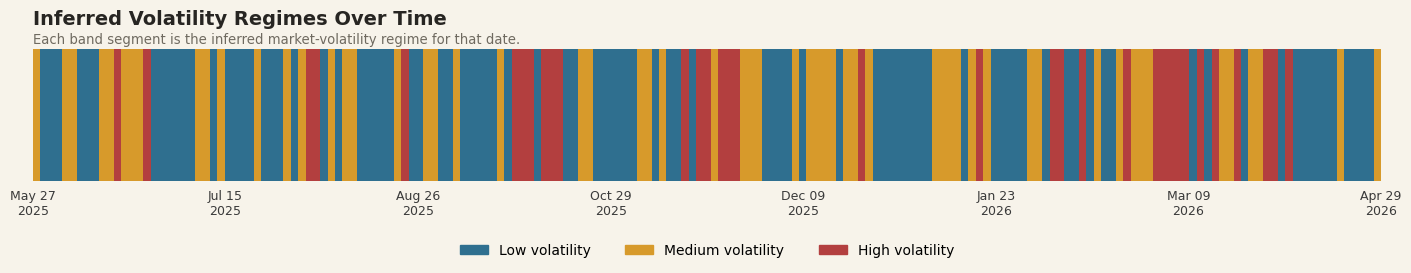

In [27]:
fig, ax = plt.subplots(figsize=(14, 2.6), constrained_layout=True)
fig.patch.set_facecolor(cream)
state_values = viz_df["ordered_state"].to_numpy().reshape(1, -1)
ax.imshow(
    state_values,
    aspect="auto",
    cmap=ListedColormap(state_colors),
    interpolation="nearest",
    extent=[0, len(viz_df) - 1, 0, 1],
)

xtick_idx = np.linspace(0, len(viz_df) - 1, 8).astype(int)
ax.set_xticks(xtick_idx)
ax.set_xticklabels(viz_df["date"].iloc[xtick_idx].dt.strftime("%b %d\n%Y"), ha="center", fontsize=9)
ax.set_yticks([])
ax.grid(False)
polish_axes(
    ax,
    "Inferred Volatility Regimes Over Time",
    "Each band segment is the inferred market-volatility regime for that date.",
)
for spine in ax.spines.values():
    spine.set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=state_colors[i]) for i in range(3)]
ax.legend(
    handles,
    [state_name_map[i] for i in range(3)],
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.38),
    columnspacing=2.5,
)
save_fig(fig, "regime_timeline_ribbon.png")
plt.show()


## 2. Transition Matrix Heatmap

The heatmap emphasizes that high-volatility days are sticky: once the process enters the high-volatility state, it is likely to remain there on the next observed day.


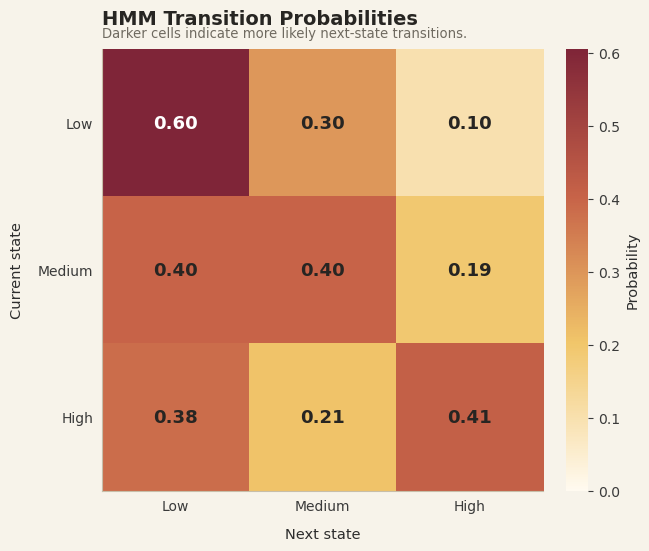

In [28]:
fig, ax = plt.subplots(figsize=(6.8, 5.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
im = ax.imshow(ordered_transmat, cmap=heat_cmap, vmin=0, vmax=ordered_transmat.max())
labels = [state_name_map[i].replace(" volatility", "") for i in range(3)]
ax.set_xticks(range(3), labels)
ax.set_yticks(range(3), labels)
ax.set_xlabel("Next state", labelpad=10)
ax.set_ylabel("Current state", labelpad=10)
ax.grid(False)
polish_axes(
    ax,
    "HMM Transition Probabilities",
    "Darker cells indicate more likely next-state transitions.",
)

for i in range(3):
    for j in range(3):
        val = ordered_transmat[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=value_color(val), fontsize=13, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Probability")
cbar.outline.set_visible(False)
save_fig(fig, "transition_matrix_heatmap.png")
plt.show()


## 3. Topic Coefficient Lollipop Plot

This chart ranks NLP topic coefficients for predicting a transition into the high-volatility state in the NLP-only classifier. Positive values indicate topics associated with higher odds of moving into high volatility.


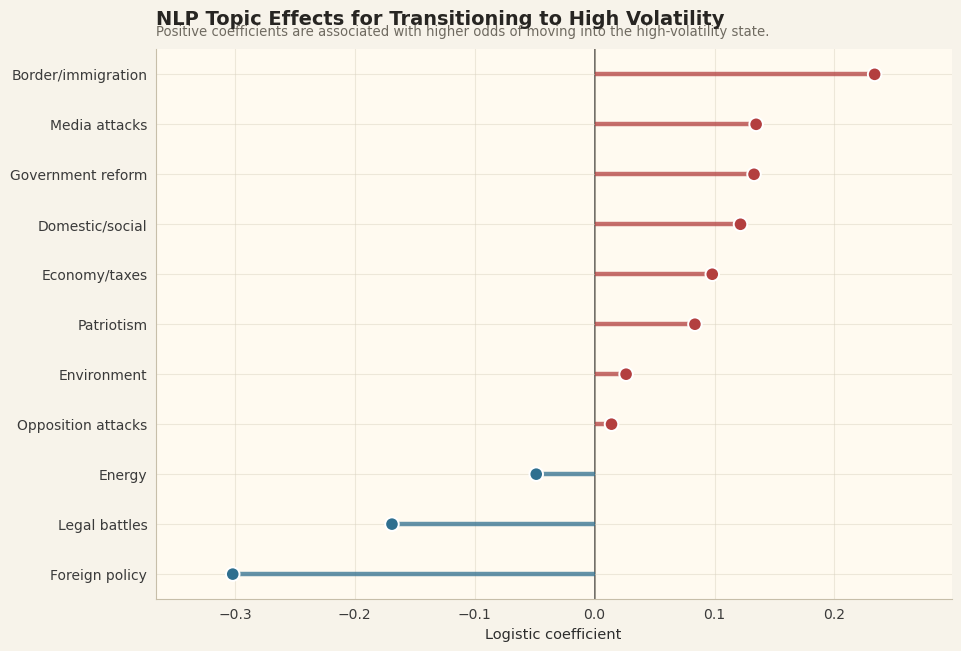

In [29]:
target_state = "next_state_2"
topic_coef = coef_nlp.loc[target_state, X_nlp_cols].rename(index=short_topic_label_map).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 6.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
y_pos = np.arange(len(topic_coef))
colors = [red if v > 0 else blue for v in topic_coef.values]
ax.hlines(y_pos, 0, topic_coef.values, color=colors, linewidth=3.2, alpha=0.75, zorder=2)
ax.scatter(topic_coef.values, y_pos, color=colors, s=95, edgecolor="white", linewidth=1.4, zorder=3)
add_zero_line(ax)
ax.set_yticks(y_pos, topic_coef.index)
ax.set_xlabel("Logistic coefficient")
polish_axes(
    ax,
    "NLP Topic Effects for Transitioning to High Volatility",
    "Positive coefficients are associated with higher odds of moving into the high-volatility state.",
)
ax.margins(x=0.12)
save_fig(fig, "topic_coefficient_lollipop.png")
plt.show()


## 4. NLP Effects Before and After Financial Controls

The paired dots show how topic coefficients change after adding financial variables. Most NLP effects shrink toward zero, suggesting the topic signal overlaps with current market conditions.


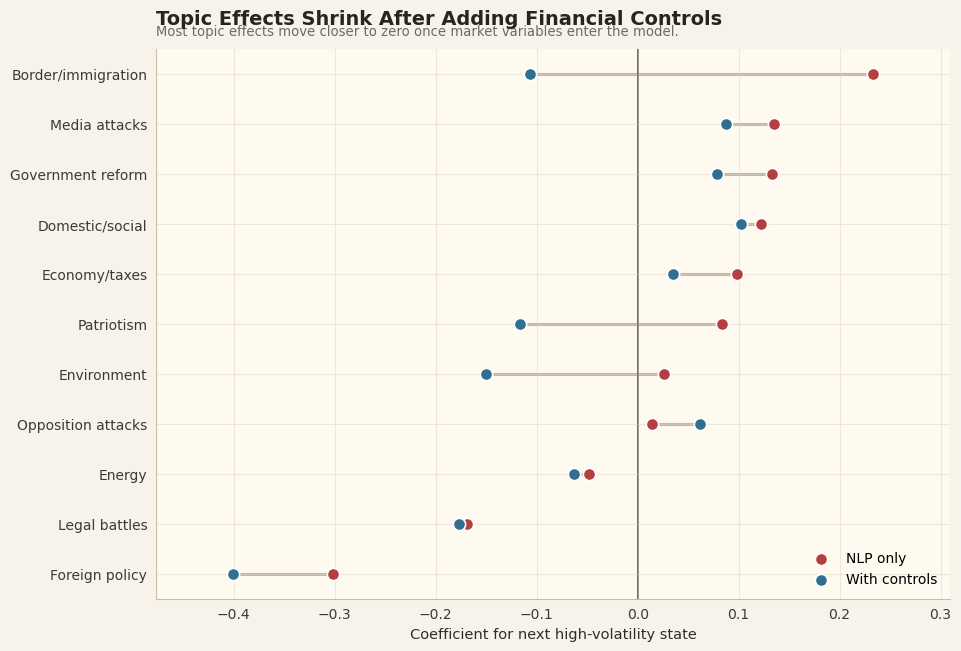

In [30]:
compare = pd.DataFrame({
    "NLP only": coef_nlp.loc[target_state, X_nlp_cols],
    "With controls": coef_full.loc[target_state, X_nlp_cols],
})
compare.index = [short_topic_label_map[i] for i in compare.index]
compare = compare.sort_values("NLP only")

fig, ax = plt.subplots(figsize=(9.5, 6.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
y_pos = np.arange(len(compare))
for y_i, (_, row) in zip(y_pos, compare.iterrows()):
    ax.plot([row["NLP only"], row["With controls"]], [y_i, y_i], color="#b8ae99", linewidth=2.2, alpha=0.85, zorder=1)
ax.scatter(compare["NLP only"], y_pos, color=red, label="NLP only", s=78, edgecolor="white", linewidth=1.2, zorder=3)
ax.scatter(compare["With controls"], y_pos, color=blue, label="With controls", s=78, edgecolor="white", linewidth=1.2, zorder=3)
add_zero_line(ax)
ax.set_yticks(y_pos, compare.index)
ax.set_xlabel("Coefficient for next high-volatility state")
polish_axes(
    ax,
    "Topic Effects Shrink After Adding Financial Controls",
    "Most topic effects move closer to zero once market variables enter the model.",
)
ax.legend(loc="lower right")
ax.margins(x=0.12)
save_fig(fig, "controls_dumbbell_plot.png")
plt.show()


## 5. Bayesian Probability-Effect Intervals

The interval plot uses the Bayesian extension results. Wide intervals crossing zero indicate that topic effects are directionally suggestive but uncertain.


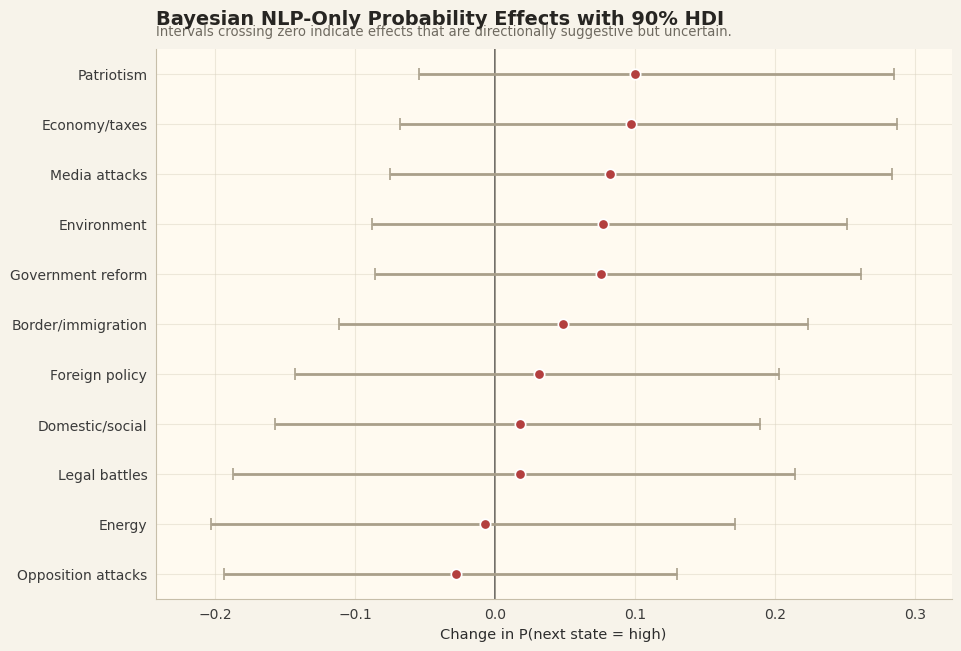

In [31]:
prob_path = Path("prob_effect_comparison.csv")
prob_effects = pd.read_csv(prob_path, index_col=0)
prob_effects["topic"] = prob_effects["feature"].map(short_topic_label_map)
prob_effects = prob_effects.sort_values("mean_prob_change_nlp_only")

fig, ax = plt.subplots(figsize=(9.5, 6.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
y_pos = np.arange(len(prob_effects))
means = prob_effects["mean_prob_change_nlp_only"]
left_err = means - prob_effects["hdi_5_nlp_only"]
right_err = prob_effects["hdi_95_nlp_only"] - means
ax.errorbar(
    means,
    y_pos,
    xerr=[left_err, right_err],
    fmt="o",
    color=red,
    ecolor="#a99f8a",
    elinewidth=2.0,
    capsize=4,
    markersize=7.5,
    markeredgecolor="white",
    markeredgewidth=1.2,
)
add_zero_line(ax)
ax.set_yticks(y_pos, prob_effects["topic"])
ax.set_xlabel("Change in P(next state = high)")
polish_axes(
    ax,
    "Bayesian NLP-Only Probability Effects with 90% HDI",
    "Intervals crossing zero indicate effects that are directionally suggestive but uncertain.",
)
ax.margins(x=0.08)
save_fig(fig, "bayesian_uncertainty_intervals.png")
plt.show()


## 6. Bayesian Probability Changes: NLP-Only vs Controls

This plot translates coefficients into probability changes. The with-controls estimates are closer to zero, reinforcing that financial variables absorb much of the apparent topic effect.


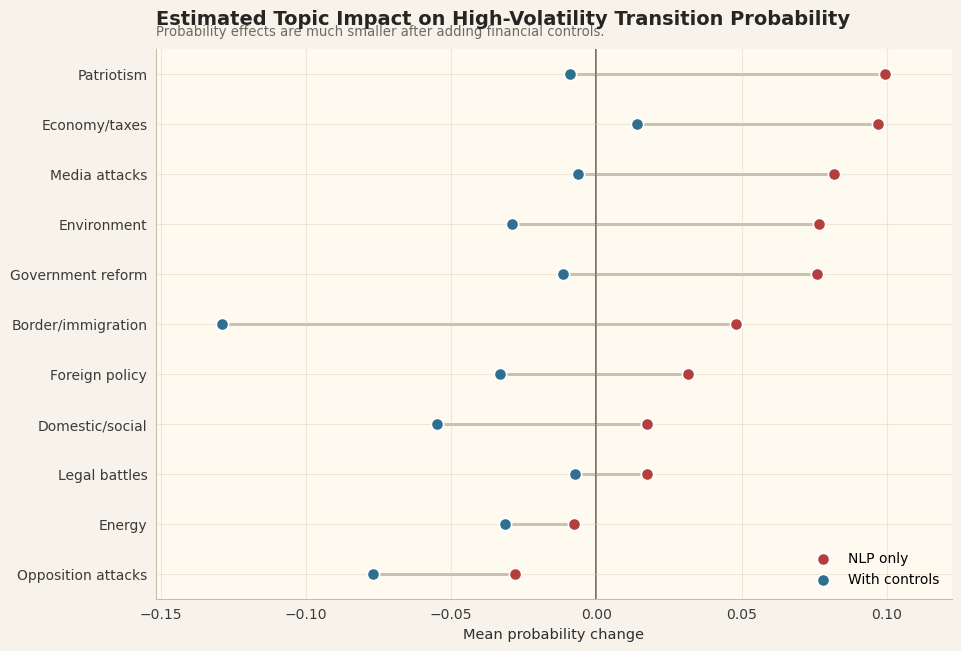

In [32]:
prob_compare = prob_effects.sort_values("mean_prob_change_nlp_only")
fig, ax = plt.subplots(figsize=(9.5, 6.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
y_pos = np.arange(len(prob_compare))
ax.scatter(prob_compare["mean_prob_change_nlp_only"], y_pos, color=red, label="NLP only", s=78, edgecolor="white", linewidth=1.2, zorder=3)
ax.scatter(prob_compare["mean_prob_change_with_controls"], y_pos, color=blue, label="With controls", s=78, edgecolor="white", linewidth=1.2, zorder=3)
for y_i, (_, row) in zip(y_pos, prob_compare.iterrows()):
    ax.plot(
        [row["mean_prob_change_nlp_only"], row["mean_prob_change_with_controls"]],
        [y_i, y_i],
        color="#b8ae99",
        linewidth=2.0,
        alpha=0.85,
        zorder=1,
    )
add_zero_line(ax)
ax.set_yticks(y_pos, prob_compare["topic"])
ax.set_xlabel("Mean probability change")
polish_axes(
    ax,
    "Estimated Topic Impact on High-Volatility Transition Probability",
    "Probability effects are much smaller after adding financial controls.",
)
ax.legend(loc="lower right")
ax.margins(x=0.1)
save_fig(fig, "probability_change_comparison.png")
plt.show()


## 7. Topic Composition by Volatility State

This heatmap compares average NMF topic scores across regimes. It helps distinguish topics that are more common during high-volatility periods from those more common in calmer states.


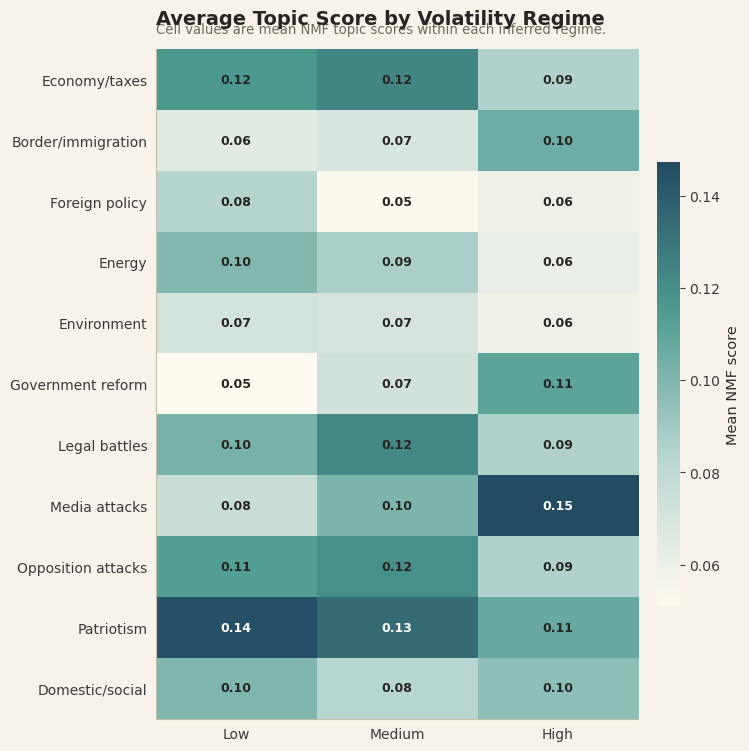

In [33]:
topic_state_summary = viz_df.groupby("ordered_state")[X_nlp_cols].mean().T
topic_state_summary.index = [short_topic_label_map[i] for i in topic_state_summary.index]
topic_state_summary.columns = [state_name_map[i].replace(" volatility", "") for i in topic_state_summary.columns]

fig, ax = plt.subplots(figsize=(7.4, 7.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
im = ax.imshow(topic_state_summary, cmap=blue_cmap, aspect="auto")
ax.set_xticks(range(topic_state_summary.shape[1]), topic_state_summary.columns)
ax.set_yticks(range(topic_state_summary.shape[0]), topic_state_summary.index)
ax.grid(False)
polish_axes(
    ax,
    "Average Topic Score by Volatility Regime",
    "Cell values are mean NMF topic scores within each inferred regime.",
)
for i in range(topic_state_summary.shape[0]):
    for j in range(topic_state_summary.shape[1]):
        val = topic_state_summary.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=value_color(val, cutoff=0.13), fontweight="bold")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean NMF score")
cbar.outline.set_visible(False)
save_fig(fig, "topic_state_composition_heatmap.png")
plt.show()


## 8. Confusion Matrix Comparison

Side-by-side confusion matrices show that adding financial controls improves classification, especially for the high-volatility state.


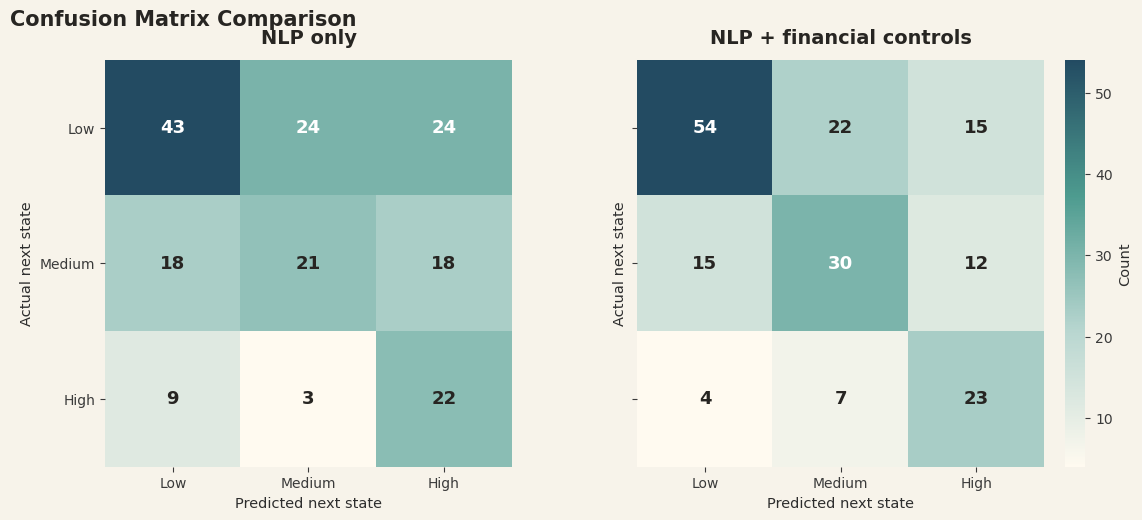

In [34]:
cms = [confusion_matrix(y_transition, pred_nlp), confusion_matrix(y_transition, pred_full)]
titles = ["NLP only", "NLP + financial controls"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.9), sharex=True, sharey=True, constrained_layout=True)
fig.patch.set_facecolor(cream)
for ax, cm, title in zip(axes, cms, titles):
    im = ax.imshow(cm, cmap=blue_cmap)
    ax.set_title(title, color=ink, fontweight="bold", pad=12)
    ax.set_xticks(range(3), ["Low", "Medium", "High"])
    ax.set_yticks(range(3), ["Low", "Medium", "High"])
    ax.set_xlabel("Predicted next state")
    ax.set_ylabel("Actual next state")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    max_val = cm.max()
    for i in range(3):
        for j in range(3):
            color = "white" if cm[i, j] > max_val * 0.55 else ink
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=13, fontweight="bold")
fig.suptitle("Confusion Matrix Comparison", x=0.02, ha="left", y=1.03, fontsize=15, fontweight="bold", color=ink)
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label="Count").outline.set_visible(False)
save_fig(fig, "confusion_matrix_comparison.png")
plt.show()


## 9. Largest VIX-Move Days

Annotating the largest absolute VIX moves grounds the regimes in concrete dates. Most of these extreme moves fall in or near the high-volatility state.


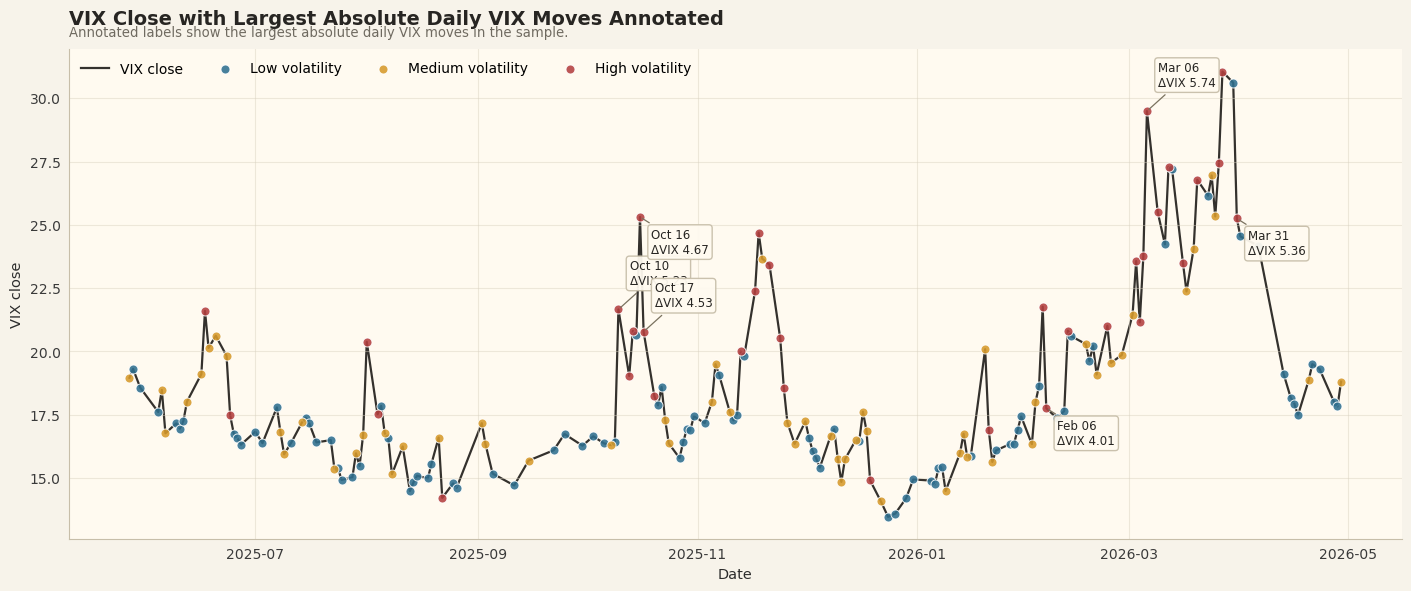

,date,abs_delta_vix,vix_close,state_label
155,2026-03-06,5.74,29.49,High volatility
170,2026-03-31,5.36,25.25,High volatility
65,2025-10-10,5.23,21.66,High volatility
69,2025-10-16,4.67,25.31,High volatility
70,2025-10-17,4.53,20.78,High volatility
139,2026-02-06,4.01,17.76,High volatility


In [35]:
top_events = viz_df.nlargest(6, "abs_delta_vix").copy()

fig, ax = plt.subplots(figsize=(14, 5.8), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax.plot(viz_df["date"], viz_df["vix_close"], color="#34312d", linewidth=1.6, label="VIX close", zorder=1)
for state in range(3):
    sub = viz_df[viz_df["ordered_state"] == state]
    ax.scatter(
        sub["date"],
        sub["vix_close"],
        s=42,
        color=state_colors[state],
        label=state_name_map[state],
        alpha=0.88,
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )

for idx, (_, row) in enumerate(top_events.iterrows()):
    offset = (8, 18 if idx % 2 == 0 else -26)
    ax.annotate(
        f"{row['date']:%b %d}\nΔVIX {row['abs_delta_vix']:.2f}",
        xy=(row["date"], row["vix_close"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=8.5,
        color=ink,
        bbox={"boxstyle": "round,pad=0.28", "fc": "#fffaf0", "ec": "#c7bea9", "alpha": 0.94},
        arrowprops={"arrowstyle": "-", "color": "#7a725f", "lw": 0.9},
    )

ax.set_xlabel("Date")
ax.set_ylabel("VIX close")
polish_axes(
    ax,
    "VIX Close with Largest Absolute Daily VIX Moves Annotated",
    "Annotated labels show the largest absolute daily VIX moves in the sample.",
)
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0, 1.0))
save_fig(fig, "annotated_high_vix_events.png")
plt.show()

top_events[["date", "abs_delta_vix", "vix_close", "state_label"]]


## 10. Model Performance Comparison

This compact performance chart summarizes the practical gain from adding financial controls: overall accuracy, macro F1, and high-state recall all improve.


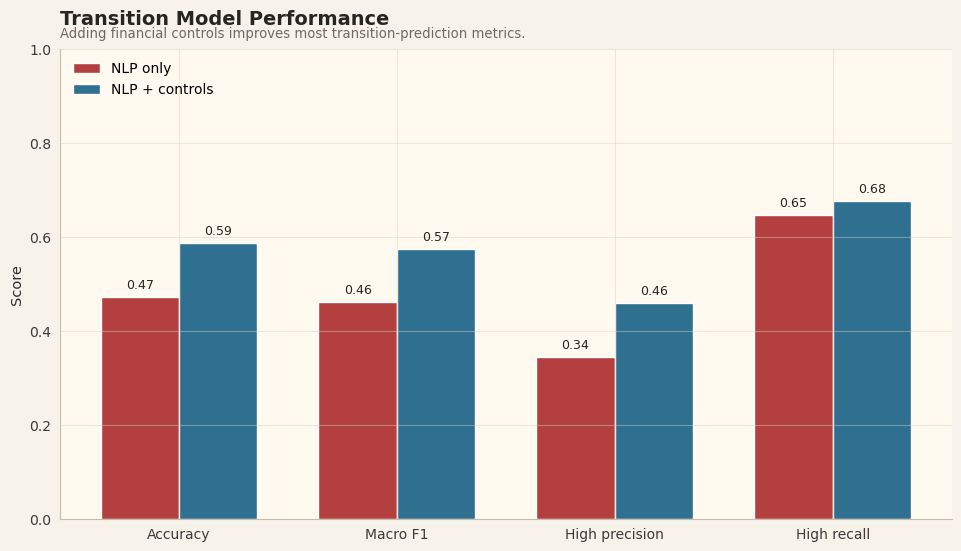

,Accuracy,Macro F1,High precision,High recall
NLP only,0.473,0.461,0.344,0.647
NLP + controls,0.588,0.574,0.460,0.676


In [36]:
def metrics_for_model(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        zero_division=0,
    )
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1.mean(),
        "High precision": precision[2],
        "High recall": recall[2],
    }

perf = pd.DataFrame({
    "NLP only": metrics_for_model(y_transition, pred_nlp),
    "NLP + controls": metrics_for_model(y_transition, pred_full),
}).T

fig, ax = plt.subplots(figsize=(9.5, 5.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
x = np.arange(len(perf.columns))
width = 0.36
bars_1 = ax.bar(x - width / 2, perf.loc["NLP only"], width, label="NLP only", color=red, edgecolor="white", linewidth=1.0)
bars_2 = ax.bar(x + width / 2, perf.loc["NLP + controls"], width, label="NLP + controls", color=blue, edgecolor="white", linewidth=1.0)
ax.set_xticks(x, perf.columns)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
polish_axes(
    ax,
    "Transition Model Performance",
    "Adding financial controls improves most transition-prediction metrics.",
)
ax.legend(loc="upper left")
for container in [bars_1, bars_2]:
    ax.bar_label(container, fmt="%.2f", padding=4, fontsize=9, color=ink)
save_fig(fig, "model_performance_comparison.png")
plt.show()

perf.round(3)


## Takeaway

Together, these plots support the main story: the HMM identifies interpretable volatility regimes, high volatility is persistent, NLP topics have suggestive relationships with high-volatility transitions, and those relationships become weaker once direct financial controls are included.
